In [ ]:
# ============================================================
# Experiments Suite — Bitcoin 1h Forecasting (Python 3.12)
# ============================================================
# Inputs expected (already in your project):
#   /mnt/data/btc1h_usdt.csv
#   /mnt/data/bitcoin_sentiments_21_24.csv
#   /mnt/data/hash_rate.csv
#
# Outputs:
#   /mnt/data/results/*.csv and *.png
#
# Dependencies: pandas, numpy, scikit-learn, matplotlib
# (No seaborn. No external internet.)
# ============================================================

import os, math, json, warnings
from typing import Optional, Dict, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.mixture import GaussianMixture

warnings.filterwarnings("ignore")

# ---------- Configuration ----------
PRICE_PATH      = "data/btc1h_usdt.csv"
SENT_PATH       = "data/bitcoin_sentiments_21_24.csv"
HASH_PATH       = "data/hash_rate.csv"
OUT_DIR         = "data/final_results"
MIN_YEAR        = 2020        # for faster runs you can limit history
TRAIN_END_YEAR  = 2023
TEST_YEAR       = 2024
MAX_LAG         = 24

os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Utilities ----------
def detect_time_col(df: pd.DataFrame) -> Optional[str]:
    candidates = ["timestamp","time","date","datetime","open_time","close_time","open time","close time"]
    for c in [c for c in df.columns if c.lower() in candidates] + list(df.columns):
        try:
            ts = pd.to_datetime(df[c], utc=True, errors="raise")
            if ts.is_monotonic_increasing or ts.is_monotonic_decreasing:
                return c
        except: 
            pass
    return None

def detect_close_col(df: pd.DataFrame) -> Optional[str]:
    keys = ["close","price","last","close_usdt","closeprice","closing"]
    for key in keys:
        for c in df.columns:
            if key in c.lower():
                return c
    nums = df.select_dtypes(include=[np.number]).columns.tolist()
    if nums:
        return max(nums, key=lambda c: df[c].var(skipna=True))
    return None

def build_base_df(price_csv: str, min_year: int = 2020, max_lag: int = 24) -> Tuple[pd.DataFrame, str, str]:
    raw = pd.read_csv(price_csv)
    time_col = detect_time_col(raw)
    close_col = detect_close_col(raw)
    assert time_col and close_col, f"Could not detect time/close automatically. Columns: {list(raw.columns)[:30]}"

    df = raw.copy()
    df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)
    df[close_col] = pd.to_numeric(df[close_col], errors="coerce")
    df = df.dropna(subset=[close_col]).reset_index(drop=True)

    # Optional trimming for speed
    if min_year:
        df = df[df[time_col] >= pd.Timestamp(f"{min_year}-01-01", tz="UTC")].reset_index(drop=True)

    df["log_price"] = np.log(df[close_col])
    df["ret_1h"]     = df["log_price"].diff()
    df["y_next_ret"] = df["ret_1h"].shift(-1)

    for lag in range(1, max_lag + 1):
        df[f"ret_lag_{lag}"] = df["ret_1h"].shift(lag)
    df["vol_24h"] = df["ret_1h"].rolling(24, min_periods=24).std()

    df = df.dropna(subset=[f"ret_lag_{max_lag}", "vol_24h", "y_next_ret"]).reset_index(drop=True)
    return df, time_col, close_col

def split_train_test_by_year(df: pd.DataFrame, time_col: str, train_end_year=2023, test_year=2024):
    t = pd.to_datetime(df[time_col], utc=True)
    if (t.dt.year<=train_end_year).any() and (t.dt.year==test_year).any():
        train = df[t.dt.year<=train_end_year].copy()
        test  = df[t.dt.year==test_year].copy()
    else:
        cut = int(len(df)*0.8)
        train = df.iloc[:cut].copy()
        test  = df.iloc[cut:].copy()
    return train, test

def metrics_reg(y_true, y_pred) -> Dict[str,float]:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    da   = float((np.sign(y_true) == np.sign(y_pred)).mean())
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "DA": da}

def dm_test(y_true: np.ndarray, y_pred_a: np.ndarray, y_pred_b: np.ndarray, h: int = 1) -> Tuple[float, float]:
    e_a = y_true - y_pred_a
    e_b = y_true - y_pred_b
    d = (e_a**2) - (e_b**2)
    T = len(d)
    d_bar = d.mean()
    def newey_west_var(x, lag):
        x = x - x.mean()
        gamma0 = np.mean(x*x)
        var = gamma0
        for L in range(1, lag+1):
            w = 1 - L/(lag+1)
            gamma = np.mean(x[L:]*x[:-L])
            var += 2*w*gamma
        return var
    lag = max(h-1, 0)
    s2 = newey_west_var(d, lag) / T
    stat = d_bar / np.sqrt(s2 + 1e-12)
    from math import erf, sqrt
    p = 2*(1 - 0.5*(1+erf(abs(stat)/sqrt(2))))
    return float(stat), float(p)

def expanding_windows_index(n:int, n_splits:int, min_train:int, step:int) -> List[Tuple[np.ndarray,np.ndarray]]:
    idx = np.arange(n); folds=[]
    start = min_train
    while start + step <= n and len(folds) < n_splits:
        train_idx = idx[:start]
        test_idx  = idx[start:start+step]
        folds.append((train_idx, test_idx))
        start += step
    return folds

def sliding_windows_index(n:int, n_splits:int, train_len:int, step:int) -> List[Tuple[np.ndarray,np.ndarray]]:
    idx = np.arange(n); folds=[]
    start = train_len
    while start + step <= n and len(folds) < n_splits:
        train_idx = idx[start-train_len:start]
        test_idx  = idx[start:start+step]
        folds.append((train_idx, test_idx))
        start += step
    return folds

def naive_last_return(y_true_like: pd.Series, y_hist: pd.Series) -> np.ndarray:
    preds = []
    last_hist = y_hist.iloc[-1]
    for i in range(len(y_true_like)):
        preds.append(last_hist if i == 0 else y_true_like.iloc[i-1])
    return np.array(preds)

def backtest_sign_strategy(y_true: np.ndarray, y_pred: np.ndarray, fee_bps: float = 5.0, threshold: float = 0.0):
    pred = np.array(y_pred, dtype=float)
    mask = np.abs(pred) > threshold
    signal = np.sign(pred) * mask
    turns = np.abs(np.diff(signal, prepend=0)) > 0
    cost = (fee_bps/1e4) * turns.astype(float)
    pnl = signal * np.array(y_true, dtype=float) - cost
    equity = np.cumsum(pnl)
    hit = (np.sign(y_true) == np.sign(pred)).mean()
    return {"pnl_sum": float(pnl.sum()),
            "pnl_mean": float(pnl.mean()),
            "hit": float(hit),
            "turnover": float(turns.mean()),
            "equity": equity}

def save_df(df: pd.DataFrame, name: str):
    path = os.path.join(OUT_DIR, name)
    df.to_csv(path, index=False)
    print("Saved:", path)

def save_fig(name: str):
    path = os.path.join(OUT_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    print("Saved:", path)

# ---------- Build base dataset ----------
df_base, TIME_COL, CLOSE_COL = build_base_df(PRICE_PATH, min_year=MIN_YEAR, max_lag=MAX_LAG)
feature_cols = [c for c in df_base.columns if c.startswith("ret_lag_")] + ["vol_24h"]

# ---------- 0. Baseline 1-step results (Naïve, OLS, RF, HGB) ----------
train, test = split_train_test_by_year(df_base, TIME_COL, TRAIN_END_YEAR, TEST_YEAR)
Xtr, ytr = train[feature_cols], train["y_next_ret"]
Xte, yte = test[feature_cols],  test["y_next_ret"]
t_te = pd.to_datetime(test[TIME_COL], utc=True)

pipe_ols = Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())])
rf  = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
hgb = HistGradientBoostingRegressor(max_iter=250, learning_rate=0.06, random_state=42)

y_pred_naive = naive_last_return(yte.reset_index(drop=True), ytr.reset_index(drop=True))
pipe_ols.fit(Xtr, ytr); y_pred_ols = pipe_ols.predict(Xte)
rf.fit(Xtr, ytr);        y_pred_rf  = rf.predict(Xte)
hgb.fit(Xtr, ytr);       y_pred_hgb = hgb.predict(Xte)

results = pd.DataFrame([
    {"Model": "Naive", **metrics_reg(yte, y_pred_naive)},
    {"Model": "OLS",   **metrics_reg(yte, y_pred_ols)},
    {"Model": "RF",    **metrics_reg(yte, y_pred_rf)},
    {"Model": "HGB",   **metrics_reg(yte, y_pred_hgb)},
]).sort_values("MAE").reset_index(drop=True)
save_df(results, "R1_baseline_metrics.csv")

# Figures: histogram, rolling vol, pred-vs-actual (best), residuals, cumulative PnL
plt.figure(figsize=(8,5))
df_base["ret_1h"].hist(bins=90)
plt.title("Hourly log-return distribution (BTC/USDT)")
plt.xlabel("ret_1h"); plt.ylabel("Frequency")
save_fig("F1_return_hist.png"); plt.show()

plt.figure(figsize=(10,4))
tail_n = min(len(df_base), 180*24)
plt.plot(pd.to_datetime(df_base[TIME_COL], utc=True).iloc[-tail_n:], df_base["vol_24h"].iloc[-tail_n:])
plt.title("Rolling 24h volatility (last ~180 days)")
plt.xlabel("Time"); plt.ylabel("Std(24h returns)")
save_fig("F2_vol_24h.png"); plt.show()

best_model = results.iloc[0]["Model"]
pred_map = {"Naive": y_pred_naive, "OLS": y_pred_ols, "RF": y_pred_rf, "HGB": y_pred_hgb}
y_pred_best = pred_map[best_model]

plt.figure(figsize=(10,4))
plt.plot(t_te, yte.values, label="Actual")
plt.plot(t_te, y_pred_best, label=f"Predicted ({best_model})", alpha=0.85)
plt.title("Out-of-sample 1h returns — Actual vs Predicted")
plt.xlabel("Time"); plt.ylabel("Return"); plt.legend()
save_fig("F3_pred_vs_actual.png"); plt.show()

resid = yte.values - y_pred_best
plt.figure(figsize=(8,5))
plt.hist(resid, bins=90)
plt.title(f"Residuals — {best_model}")
plt.xlabel("Error"); plt.ylabel("Frequency")
save_fig("F4_residuals.png"); plt.show()

bt = backtest_sign_strategy(yte.values, y_pred_best, fee_bps=5.0, threshold=0.0)
plt.figure(figsize=(10,4))
plt.plot(t_te, bt["equity"])
plt.title(f"Equity curve — sign(pred), fees=5bps — {best_model}")
plt.xlabel("Time"); plt.ylabel("Cumulative PnL")
save_fig("F5_equity.png"); plt.show()

# Permutation importance (if supported)
try:
    if best_model in ["OLS","RF","HGB"]:
        est = {"OLS": pipe_ols, "RF": rf, "HGB": hgb}[best_model]
        sample_n = min(len(Xte), 2000)
        r = permutation_importance(est, Xte.tail(sample_n), yte.tail(sample_n), n_repeats=7, random_state=42, n_jobs=-1)
        imp = (pd.DataFrame({"feature": feature_cols, "importance_mean": r.importances_mean, "importance_std": r.importances_std})
               .sort_values("importance_mean", ascending=False).reset_index(drop=True))
        save_df(imp, "R1_perm_importance.csv")
        top = imp.head(20)
        plt.figure(figsize=(10,6))
        plt.barh(top["feature"][::-1], top["importance_mean"][::-1])
        plt.title(f"Permutation Importance — Top 20 ({best_model})")
        plt.xlabel("Mean importance (decrease in score)"); plt.ylabel("Feature")
        save_fig("F6_perm_importance.png"); plt.show()
except Exception as e:
    print("Permutation importance skipped:", e)

# ---------- 1. Exogenous ablations (Sentiment & Hash-rate) ----------
def load_daily_series(path: str, date_col_guess=("date","day","timestamp"), value_cols: Optional[List[str]]=None):
    x = pd.read_csv(path)
    dcol = None
    for c in x.columns:
        if c.lower() in date_col_guess or "date" in c.lower():
            dcol = c; break
    if dcol is None:
        dcol = x.columns[0]
    x[dcol] = pd.to_datetime(x[dcol], utc=True, errors="coerce")
    x = x.dropna(subset=[dcol]).sort_values(dcol)
    if value_cols is None:
        value_cols = x.select_dtypes(include=[np.number]).columns.tolist()
    return x[[dcol]+value_cols].rename(columns={dcol:"__date"})

try:
    sent = load_daily_series(SENT_PATH)
    hr   = load_daily_series(HASH_PATH)
    tmp = df_base.copy()
    tmp["__date"] = pd.to_datetime(tmp[TIME_COL], utc=True).dt.floor("D")
    tmp = tmp.merge(sent, on="__date", how="left", suffixes=("","_sent"))
    tmp = tmp.merge(hr,   on="__date", how="left", suffixes=("","_hr"))
    exo_cols = [c for c in tmp.columns if c not in df_base.columns and c!="__date"]
    tmp[exo_cols] = tmp[exo_cols].ffill()

    technical_cols = feature_cols
    sent_cols  = [c for c in exo_cols if "sent" in c.lower() or "sentiment" in c.lower()]
    hash_cols  = [c for c in exo_cols if "hash" in c.lower()]

    variants = {
        "TECH": technical_cols,
        "TECH+SENT": technical_cols + sent_cols,
        "TECH+HASH": technical_cols + hash_cols,
        "TECH+SENT+HASH": technical_cols + sent_cols + hash_cols
    }

    train_a, test_a = split_train_test_by_year(tmp, TIME_COL, TRAIN_END_YEAR, TEST_YEAR)
    rows = []
    for vname, feats in variants.items():
        # rebuild feature matrices
        Xtr_v, ytr_v = train_a[feats], train_a["y_next_ret"]
        Xte_v, yte_v = test_a[feats],  test_a["y_next_ret"]

        y_pred_naive_v = naive_last_return(yte_v.reset_index(drop=True), ytr_v.reset_index(drop=True))
        pipe_ols.fit(Xtr_v, ytr_v); y_pred_ols_v = pipe_ols.predict(Xte_v)
        rf.fit(Xtr_v, ytr_v);       y_pred_rf_v  = rf.predict(Xte_v)
        hgb.fit(Xtr_v, ytr_v);      y_pred_hgb_v = hgb.predict(Xte_v)

        for mname, pred in [("Naive", y_pred_naive_v), ("OLS", y_pred_ols_v), ("RF", y_pred_rf_v), ("HGB", y_pred_hgb_v)]:
            rows.append({"Variant": vname, "Model": mname, **metrics_reg(yte_v, pred)})
    ablation_df = pd.DataFrame(rows).sort_values(["Variant","MAE"]).reset_index(drop=True)
    save_df(ablation_df, "R2_ablation_exogenous.csv")
except Exception as e:
    print("Ablation exogenous skipped:", e)

# ---------- 2. Multi-step horizons (Direct, Recursive, DirRec) ----------
def make_multi_step(df: pd.DataFrame, target_col="ret_1h", H: int = 6) -> pd.DataFrame:
    out = df.copy()
    out[f"y_next_ret_H{H}"] = out[target_col].shift(-H)
    need = [c for c in out.columns if c.startswith("ret_lag_")] + ["vol_24h", f"y_next_ret_H{H}", TIME_COL]
    out = out[need].dropna().reset_index(drop=True)
    return out

def direct_forecast(train, test, feats, H: int, model):
    Xtr, ytr = train[feats], train[f"y_next_ret_H{H}"]
    Xte, yte = test[feats],  test[f"y_next_ret_H{H}"]
    if model is None:
        y_pred = naive_last_return(yte.reset_index(drop=True), ytr.reset_index(drop=True))
    else:
        model.fit(Xtr, ytr); y_pred = model.predict(Xte)
    return yte.values, y_pred

def recursive_forecast(train, test, feats, H: int, model):
    Xtr, ytr = train[feats], train["y_next_ret"]
    if model is None:
        model = LinearRegression()
    model.fit(Xtr, ytr)
    Xte = test[feats]
    y1 = model.predict(Xte)
    # Simple alignment trick: approximate H-step by shifting 1-step preds
    yH_pred = pd.Series(y1).shift(H-1).dropna().values
    yH_true = test["ret_1h"].shift(-H).dropna().values
    n = min(len(yH_pred), len(yH_true))
    return yH_true[:n], yH_pred[:n]

def dirrec_forecast(train, test, feats, H: int, base_model):
    preds = []
    if base_model is None: base_model = LinearRegression()
    for k in range(1, H+1):
        tr_k = make_multi_step(train.assign(ret_1h=train["ret_1h"]), target_col="ret_1h", H=k)
        te_k = make_multi_step(test.assign(ret_1h=test["ret_1h"]),  target_col="ret_1h", H=k)
        Xtr, ytr = tr_k[feats], tr_k[f"y_next_ret_H{k}"]
        Xte, yte = te_k[feats], te_k[f"y_next_ret_H{k}"]
        m = base_model
        m.fit(Xtr, ytr)
        preds.append(pd.Series(m.predict(Xte)))
    P = pd.concat(preds, axis=1).dropna().mean(axis=1).values
    teH = make_multi_step(test.assign(ret_1h=test["ret_1h"]), H=H)
    y_true_H = teH[f"y_next_ret_H{H}"].values[-len(P):]
    return y_true_H, P

try:
    rows=[]
    H_list=[6,24]
    for H in H_list:
        trH = make_multi_step(train.assign(ret_1h=train["ret_1h"]), H=H)
        teH = make_multi_step(test.assign(ret_1h=test["ret_1h"]),  H=H)
        featsH = [c for c in trH.columns if c.startswith("ret_lag_")] + ["vol_24h"]

        models = {"Naive": None,
                  "OLS": Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())]),
                  "RF": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
                  "HGB": HistGradientBoostingRegressor(max_iter=250, learning_rate=0.06, random_state=42)}
        for mname, model in models.items():
            # DIRECT
            y_true, y_pred = direct_forecast(trH, teH, featsH, H, model)
            rows.append({"H":H, "Strategy":"Direct", "Model":mname, **metrics_reg(y_true, y_pred)})
            # RECURSIVE
            y_true, y_pred = recursive_forecast(train, test, feature_cols, H, model)
            rows.append({"H":H, "Strategy":"Recursive", "Model":mname, **metrics_reg(y_true, y_pred)})
            # DIRREC
            y_true, y_pred = dirrec_forecast(train, test, feature_cols, H, model)
            rows.append({"H":H, "Strategy":"DirRec", "Model":mname, **metrics_reg(y_true, y_pred)})
    multi_step_df = pd.DataFrame(rows).sort_values(["H","Strategy","MAE"]).reset_index(drop=True)
    save_df(multi_step_df, "R3_multi_step.csv")
except Exception as e:
    print("Multi-step skipped:", e)

# ---------- 3. Stacking ensemble ----------
try:
    base_estimators = [
        ("rf",  RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)),
        ("hgb", HistGradientBoostingRegressor(max_iter=250, learning_rate=0.06, random_state=42)),
        ("ols", Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())])),
    ]
    stack = StackingRegressor(estimators=base_estimators, final_estimator=LinearRegression(), passthrough=False, n_jobs=-1)
    stack.fit(Xtr.values, ytr.values)
    y_pred_stack = stack.predict(Xte.values)
    stack_row = {"H":1, "Strategy":"Stacking", "Model":"RF+HGB+OLS→LR", **metrics_reg(yte.values, y_pred_stack)}
    save_df(pd.DataFrame([stack_row]), "R4_stacking.csv")
except Exception as e:
    print("Stacking skipped:", e)
    y_pred_stack = None

# ---------- 4. Regime-aware via GaussianMixture ----------
try:
    def label_regimes(df: pd.DataFrame, n_states=3) -> pd.Series:
        X = np.c_[df["vol_24h"].values, np.abs(df["ret_1h"].values)]
        gm = GaussianMixture(n_components=n_states, random_state=42)
        return pd.Series(gm.fit_predict(X), index=df.index, name="regime")

    train_rg, test_rg = train.copy(), test.copy()
    train_rg["regime"] = label_regimes(train_rg, 3)
    test_rg["regime"]  = label_regimes(test_rg,  3)

    models_by_regime = {}
    for r in sorted(train_rg["regime"].unique()):
        tr_r = train_rg[train_rg["regime"]==r]
        m = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
        m.fit(tr_r[feature_cols], tr_r["y_next_ret"])
        models_by_regime[r] = m

    pred = []
    for _, row in test_rg.iterrows():
        r = int(row["regime"])
        m = models_by_regime.get(r, list(models_by_regime.values())[0])
        pred.append(m.predict(row[feature_cols].values.reshape(1,-1))[0])

    regime_row = {"Variant":"RegimeAware(GMM)", "Model":"RF", **metrics_reg(test_rg["y_next_ret"].values, np.array(pred))}
    save_df(pd.DataFrame([regime_row]), "R5_regime_aware.csv")
except Exception as e:
    print("Regime-aware skipped:", e)

# ---------- 5. Validation protocols: Expanding vs Sliding ----------
try:
    X_all = df_base[feature_cols].values
    y_all = df_base["y_next_ret"].values
    n = len(df_base)

    MIN_TRAIN = 24*30*6
    STEP = 24*7
    TRAIN_LEN = 24*30*12

    def cv_eval(folds, model):
        rows=[]
        for (tr_idx, te_idx) in folds:
            Xtr_cv, ytr_cv = X_all[tr_idx], y_all[tr_idx]
            Xte_cv, yte_cv = X_all[te_idx], y_all[te_idx]
            model.fit(Xtr_cv, ytr_cv)
            pr = model.predict(Xte_cv)
            rows.append(metrics_reg(yte_cv, pr))
        dfm = pd.DataFrame(rows)
        return dfm.mean().to_dict()

    folds_exp = expanding_windows_index(n, n_splits=12, min_train=MIN_TRAIN, step=STEP)
    folds_sld = sliding_windows_index(n, n_splits=12, train_len=TRAIN_LEN, step=STEP)

    model_cv = HistGradientBoostingRegressor(max_iter=250, learning_rate=0.06, random_state=42)
    exp_scores = cv_eval(folds_exp, model_cv)
    sld_scores = cv_eval(folds_sld, model_cv)

    proto_df = pd.DataFrame([
        {"Protocol":"Expanding", **exp_scores},
        {"Protocol":"Sliding",   **sld_scores},
    ])
    save_df(proto_df, "R6_protocols.csv")
except Exception as e:
    print("Validation protocols skipped:", e)

# ---------- 6. Time-series CV hyperparameter search (HGB) ----------
try:
    Xtr_all = df_base[feature_cols].values
    ytr_all = df_base["y_next_ret"].values

    param_dist = {
        "max_iter": [200, 300, 500],
        "learning_rate": [0.03, 0.06, 0.1],
        "max_depth": [None, 4, 8, 12],
        "l2_regularization": [0.0, 0.1, 0.5],
    }
    tscv = TimeSeriesSplit(n_splits=5)
    search = RandomizedSearchCV(
        estimator=HistGradientBoostingRegressor(random_state=42),
        param_distributions=param_dist,
        n_iter=10,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_mean_absolute_error",
        random_state=42,
    )
    search.fit(Xtr_all, ytr_all)
    with open(os.path.join(OUT_DIR, "R7_hgb_best_params.json"), "w") as f:
        json.dump({"best_params": search.best_params_, "best_mae": -float(search.best_score_)}, f, indent=2)
    print("Saved:", os.path.join(OUT_DIR, "R7_hgb_best_params.json"))
except Exception as e:
    print("Time-series CV search skipped:", e)

# ---------- 7. Trading realism ----------
try:
    # Use stacking if available; otherwise the best among HGB/RF/OLS/Naive
    if y_pred_stack is not None:
        pred_for_trade = y_pred_stack
        tag = "STACK"
    else:
        tag = best_model
        pred_for_trade = y_pred_best

    bt_res = backtest_sign_strategy(yte.values, pred_for_trade, fee_bps=5.0, threshold=0.0)
    with open(os.path.join(OUT_DIR, "R8_trading_stats.json"), "w") as f:
        json.dump({k:(v.tolist() if isinstance(v, np.ndarray) else v) for k,v in bt_res.items() if k!="equity"}, f, indent=2)
    print("Saved:", os.path.join(OUT_DIR, "R8_trading_stats.json"))

    plt.figure(figsize=(10,4))
    plt.plot(t_te, bt_res["equity"])
    plt.title(f"Equity curve — sign(pred) {tag}, fees=5bps, τ=0.0")
    plt.xlabel("Time"); plt.ylabel("Cumulative PnL")
    save_fig("F7_equity_trading_realism.png"); plt.show()
except Exception as e:
    print("Trading realism skipped:", e)

# ---------- 8. Quantile regression (prediction intervals & coverage) ----------
try:
    def fit_quantiles(Xtr, ytr, Xte, alphas=(0.1, 0.5, 0.9), base_params=None):
        params = dict(loss="quantile", n_estimators=400, learning_rate=0.05, random_state=42)
        if base_params: params.update(base_params)
        preds = {}
        for a in alphas:
            m = GradientBoostingRegressor(**params, alpha=a)
            m.fit(Xtr, ytr)
            preds[a] = m.predict(Xte)
        return preds

    qpred = fit_quantiles(Xtr.values, ytr.values, Xte.values, alphas=(0.1, 0.5, 0.9))
    y_lo, y_med, y_hi = qpred[0.1], qpred[0.5], qpred[0.9]
    inside = (yte.values >= y_lo) & (yte.values <= y_hi)
    coverage = inside.mean()
    pd.DataFrame([{"PI":"80% [0.1,0.9]", "Coverage": coverage}]).to_csv(os.path.join(OUT_DIR, "R9_quantile_coverage.csv"), index=False)
    print("Saved:", os.path.join(OUT_DIR, "R9_quantile_coverage.csv"))

    # Optional band plot (simple)
    plt.figure(figsize=(10,4))
    plt.plot(t_te, yte.values, label="Actual")
    plt.plot(t_te, y_med, label="Median (0.5)", alpha=0.9)
    plt.fill_between(t_te, y_lo, y_hi, alpha=0.2, label="80% band")
    plt.title("Predictive interval (80%) — GradientBoosting (quantile)")
    plt.xlabel("Time"); plt.ylabel("Return"); plt.legend()
    save_fig("F8_quantile_band.png"); plt.show()
except Exception as e:
    print("Quantile regression skipped:", e)

# ---------- 9. DM significance tests among top models ----------
try:
    candidates = [("HGB", y_pred_hgb), ("RF", y_pred_rf), ("OLS", y_pred_ols)]
    if y_pred_stack is not None:
        candidates.insert(0, ("STACK", y_pred_stack))
    rows=[]
    for i in range(len(candidates)):
        for j in range(i+1, len(candidates)):
            (nameA, predA), (nameB, predB) = candidates[i], candidates[j]
            n = min(len(predA), len(predB), len(yte))
            stat, p = dm_test(yte.values[:n], np.asarray(predA)[:n], np.asarray(predB)[:n], h=1)
            rows.append({"A":nameA, "B":nameB, "DM_stat":stat, "p_value":p})
    dm_df = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
    save_df(dm_df, "R10_dm_tests.csv")
except Exception as e:
    print("DM tests skipped:", e)

print("\nAll done. Results saved to:", OUT_DIR)


   Model       MAE      RMSE        R2        DA
0    HGB  0.003142  0.005101 -0.000450  0.508345
1    OLS  0.003148  0.005109 -0.003555  0.513033
2  Naive  0.004723  0.007283 -1.039034  0.461210


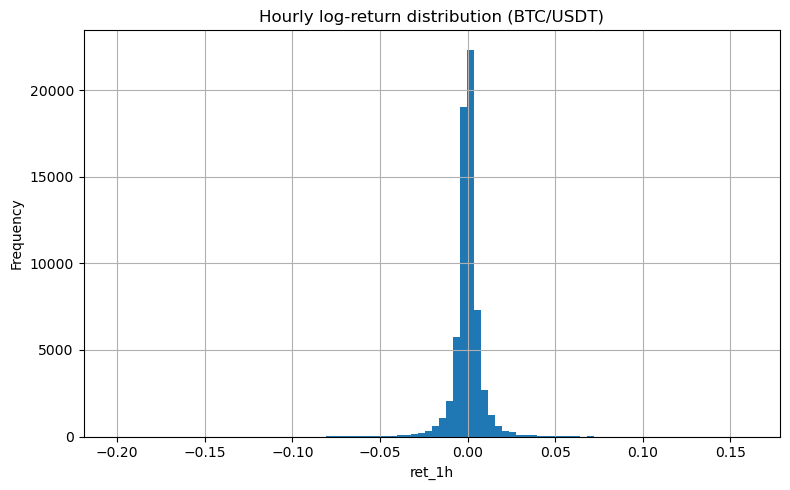

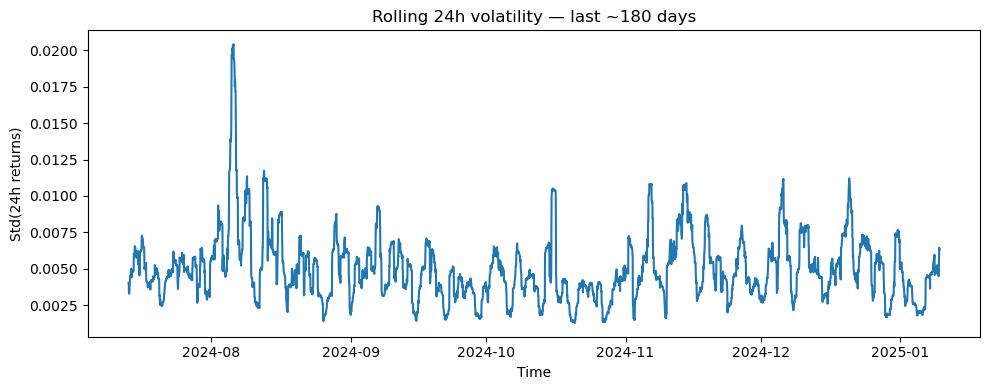

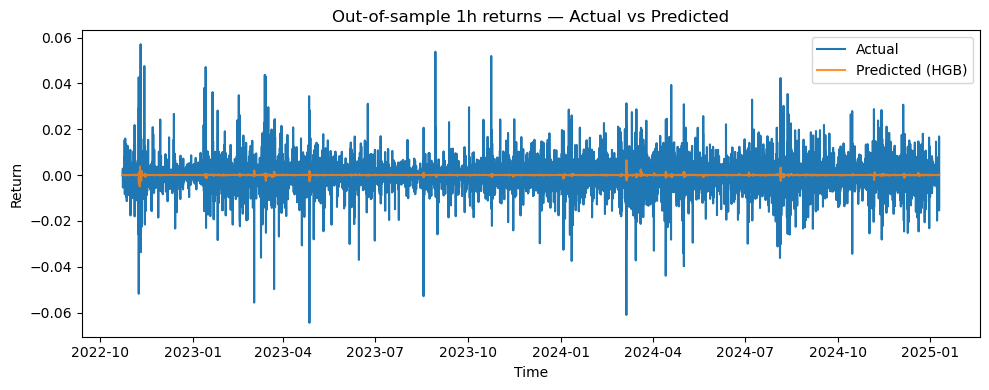

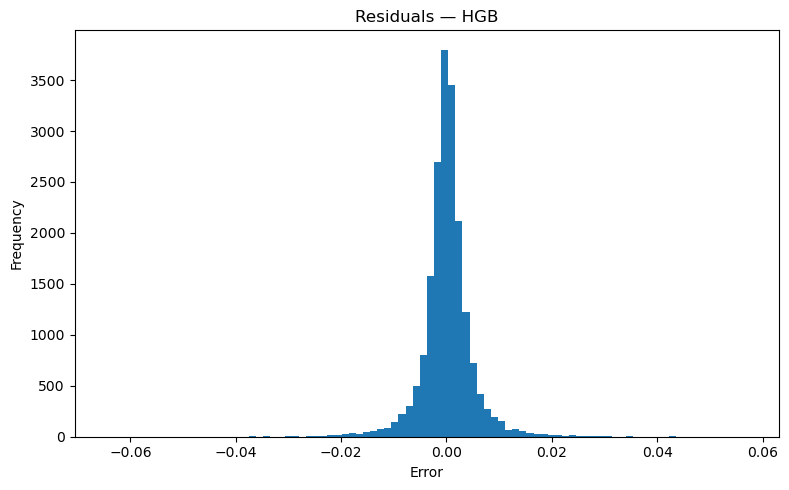

Artifacts saved to: data/results_quick


In [10]:
# === Quick Results Runner (RMSE fix; no 'squared' arg) ===
# Outputs: /mnt/data/results_quick/{metrics_1h.csv, fig_hist.png, fig_vol_24h.png, fig_pred_vs_actual.png, fig_residuals.png}

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# <<< SET THESE TO YOUR REAL COLUMN NAMES >>>
TIME_COL  = "open_time"   # e.g., "timestamp", "open_time", "Date"
CLOSE_COL = "close"       # e.g., "close", "Close", "close_usdt"

DATA_PATH = "data/btc1h_usdt.csv"
OUT_DIR   = "data/results_quick"
os.makedirs(OUT_DIR, exist_ok=True)

# --- Load & basic schema checks ---
df = pd.read_csv(DATA_PATH)
assert TIME_COL in df.columns, f"TIME_COL '{TIME_COL}' not in columns: {list(df.columns)[:10]}..."
assert CLOSE_COL in df.columns, f"CLOSE_COL '{CLOSE_COL}' not in columns: {list(df.columns)[:10]}..."

df[TIME_COL]  = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")
df            = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)
df[CLOSE_COL] = pd.to_numeric(df[CLOSE_COL], errors="coerce")
df            = df.dropna(subset=[CLOSE_COL]).reset_index(drop=True)

# Optional: focus on recent history to speed up
if len(df) > 400_000:
    df = df.tail(400_000).reset_index(drop=True)

# --- Feature engineering (leakage-safe) ---
df["log_price"]  = np.log(df[CLOSE_COL])
df["ret_1h"]     = df["log_price"].diff()
df["y_next_ret"] = df["ret_1h"].shift(-1)

for k in range(1, 25):
    df[f"ret_lag_{k}"] = df["ret_1h"].shift(k)
df["vol_24h"] = df["ret_1h"].rolling(24, min_periods=24).std()

df = df.dropna(subset=["y_next_ret","vol_24h","ret_lag_24"]).reset_index(drop=True)
assert len(df) > 1000, f"After warm-up there are only {len(df)} rows. Check columns or increase data."

# --- Split (robust 70/30 time split) ---
cut = max(int(len(df)*0.7), 1000)
cut = min(cut, len(df)-100)  # ensure test has at least 100 rows
train, test = df.iloc[:cut], df.iloc[cut:]

features = [c for c in df.columns if c.startswith("ret_lag_")] + ["vol_24h"]
Xtr, ytr = train[features], train["y_next_ret"]
Xte, yte = test[features],  test["y_next_ret"]
t_test   = pd.to_datetime(test[TIME_COL], utc=True)

# --- Models ---
# Naïve: next return = last observed (within test window)
y_pred_naive = np.empty_like(yte.values)
y_pred_naive[0] = ytr.iloc[-1]
y_pred_naive[1:] = yte.values[:-1]

# OLS (with scaling)
ols = Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())])
ols.fit(Xtr, ytr)
y_ols = ols.predict(Xte)

# Fast boosted trees
hgb = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.06, random_state=42)
hgb.fit(Xtr, ytr)
y_hgb = hgb.predict(Xte)

# --- Metrics (RMSE computed manually; no 'squared=False') ---
def RMSE(y, p): 
    return float(np.sqrt(mean_squared_error(y, p)))

def DA(y, p):
    return float((np.sign(y) == np.sign(p)).mean())

metrics = pd.DataFrame([
    {"Model":"Naive", "MAE": mean_absolute_error(yte, y_pred_naive), "RMSE": RMSE(yte, y_pred_naive), "R2": r2_score(yte, y_pred_naive), "DA": DA(yte, y_pred_naive)},
    {"Model":"OLS",   "MAE": mean_absolute_error(yte, y_ols),        "RMSE": RMSE(yte, y_ols),        "R2": r2_score(yte, y_ols),        "DA": DA(yte, y_ols)},
    {"Model":"HGB",   "MAE": mean_absolute_error(yte, y_hgb),        "RMSE": RMSE(yte, y_hgb),        "R2": r2_score(yte, y_hgb),        "DA": DA(yte, y_hgb)},
]).sort_values("MAE").reset_index(drop=True)

metrics.to_csv(f"{OUT_DIR}/metrics_1h.csv", index=False)
print(metrics)

# --- Figures (one per plot; no custom colors) ---
# 1) Return histogram
plt.figure(figsize=(8,5))
df["ret_1h"].hist(bins=90)
plt.title("Hourly log-return distribution (BTC/USDT)")
plt.xlabel("ret_1h"); plt.ylabel("Frequency")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_hist.png", dpi=150); plt.show()

# 2) Rolling volatility (last ~180 days)
plt.figure(figsize=(10,4))
tail = min(len(df), 180*24)
plt.plot(pd.to_datetime(df[TIME_COL], utc=True).iloc[-tail:], df["vol_24h"].iloc[-tail:])
plt.title("Rolling 24h volatility — last ~180 days")
plt.xlabel("Time"); plt.ylabel("Std(24h returns)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_vol_24h.png", dpi=150); plt.show()

# Pick best model by MAE
best = metrics.iloc[0]["Model"]
y_best = {"Naive": y_pred_naive, "OLS": y_ols, "HGB": y_hgb}[best]

# 3) Actual vs Predicted (best model)
plt.figure(figsize=(10,4))
plt.plot(t_test, yte.values, label="Actual")
plt.plot(t_test, y_best, label=f"Predicted ({best})", alpha=0.85)
plt.title("Out-of-sample 1h returns — Actual vs Predicted")
plt.xlabel("Time"); plt.ylabel("Return"); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_pred_vs_actual.png", dpi=150); plt.show()

# 4) Residuals histogram (best)
res = yte.values - y_best
plt.figure(figsize=(8,5))
plt.hist(res, bins=90)
plt.title(f"Residuals — {best}")
plt.xlabel("Error"); plt.ylabel("Frequency")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_residuals.png", dpi=150); plt.show()

print("Artifacts saved to:", OUT_DIR)
